# This notebook calculates the expected event rate at DUNE across different zenith angle and energy bins.

## 1. Atmospheric neutrino flux

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.interpolate import RegularGridInterpolator

with open('hms-nu-20-01-000.d') as f:
    with open('hms-nu-20-01-n3650.d') as l:
        lines_min = (line for line in f if 'average' not in line and 'Enu' not in line)
        lines_max = (line for line in l if 'average' not in line and 'Enu' not in line)
        all_flux_data_min = np.loadtxt(lines_min)
        all_flux_data_max = np.loadtxt(lines_max)  

        flux_data_numu = (all_flux_data_min[:, [0, 1]] + all_flux_data_max[:, [0, 1]]) / 2
        numu_uncertainty = np.abs(all_flux_data_min[:, [0, 1]] - all_flux_data_max[:, [0, 1]]) / 2

        flux_data_numubar = (all_flux_data_min[:, [0, 2]] + all_flux_data_max[:, [0, 2]]) / 2
        numubar_uncertainty = np.abs(all_flux_data_min[:, [0, 2]] - all_flux_data_max[:, [0, 2]]) / 2

        flux_data_nue = (all_flux_data_min[:, [0, 3]] + all_flux_data_max[:, [0, 3]]) / 2
        nue_uncertainty = np.abs(all_flux_data_min[:, [0, 3]] - all_flux_data_max[:, [0, 3]]) / 2

        flux_data_nuebar = (all_flux_data_min[:, [0, 4]] + all_flux_data_max[:, [0, 4]]) / 2
        nuebar_uncertainty = np.abs(all_flux_data_min[:, [0, 4]] - all_flux_data_max[:, [0, 4]]) / 2

In [38]:
n_energy = 101
energies = all_flux_data_min[:n_energy, 0]
num_cos = len(all_flux_data_min) // n_energy
cos_bins_centers = np.linspace(-0.95, 0.95, num_cos)


def make_interpolator(data):
    """Create a 2D flux interpolator from [energy, value] blocks."""
    values = data[:, 1].reshape(num_cos, n_energy)
    return RegularGridInterpolator(
        (cos_bins_centers, energies),
        values,
        #method="cubic",
        method = "linear",
        bounds_error=False,
        fill_value=0,
    )


flux_data = {
    "numu": flux_data_numu,
    "numubar": flux_data_numubar,
    "nue": flux_data_nue,
    "nuebar": flux_data_nuebar,
}

uncertainty_data = {
    "numu": numu_uncertainty,
    "numubar": numubar_uncertainty,
    "nue": nue_uncertainty,
    "nuebar": nuebar_uncertainty,
}

flux_interpolators = {
    flavor: make_interpolator(data)
    for flavor, data in flux_data.items()
}

uncertainty_interpolators = {
    flavor: make_interpolator(data)
    for flavor, data in uncertainty_data.items()
}


def get_flux(cos_theta, energy, flavor="numu", uncertainty=False):
    """Return interpolated flux or its uncertainty for a flavor."""
    interpolators = uncertainty_interpolators if uncertainty else flux_interpolators
    points = np.column_stack([np.atleast_1d(cos_theta), np.atleast_1d(energy)])
    return interpolators[flavor](points)


# Example: central value and uncertainty for nu_mu.
test_cos = -0.12
test_energy = 1.5
print(f"nu_mu flux: {get_flux(test_cos, test_energy)[0]:.2e}")
print(f"nu_mu uncertainty: {get_flux(test_cos, test_energy, uncertainty=True)[0]:.2e}")
print(f"nu_mu-bar flux: {get_flux(test_cos, test_energy, flavor='numubar')[0]:.2e}")

nu_mu flux: 7.10e+01
nu_mu uncertainty: 1.07e+00
nu_mu-bar flux: 6.82e+01


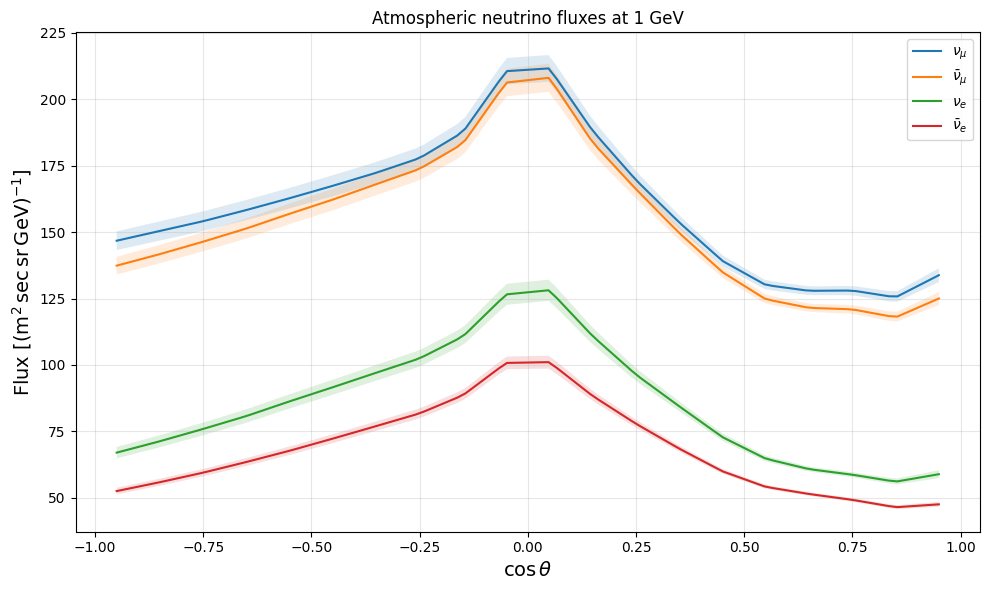

In [39]:
cos_grid = np.linspace(-0.95, 0.95, 100)
energy_to_plot = energies[20]
flavors = ["numu", "numubar", "nue", "nuebar"]
flavor_labels = {
    "numu": r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
    "nue": r"$\nu_e$",
    "nuebar": r"$\bar{\nu}_e$",
}

plt.figure(figsize=(10, 6))
for flavor in flavors:
    flux_values = np.array([
        get_flux(cos, energy_to_plot, flavor=flavor)[0]
        for cos in cos_grid
    ])
    uncertainty_values = np.array([
        get_flux(cos, energy_to_plot, flavor=flavor, uncertainty=True)[0]
        for cos in cos_grid
    ])

    plt.plot(cos_grid, flux_values, label=flavor_labels[flavor])
    plt.fill_between(
        cos_grid,
        flux_values - uncertainty_values,
        flux_values + uncertainty_values,
        alpha=0.15,
    )

plt.xlabel(r"$\cos\theta$", fontsize=14)
plt.ylabel(r"Flux $[(\mathrm{m^2\,sec\,sr\,GeV})^{-1}]$", fontsize=14)
plt.title(f"Atmospheric neutrino fluxes at {energy_to_plot:.2g} GeV")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("flux_zenith_solar_max.pdf", dpi=300)
plt.show()

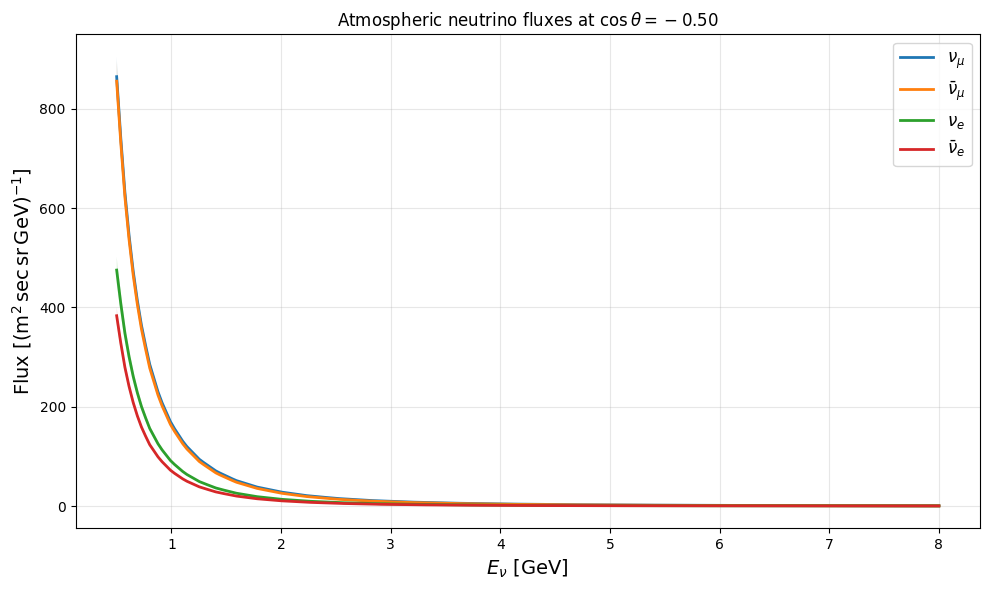

In [45]:
# Plot flux vs energy at a given zenith angle
cos_z_fixed = -0.5  # Fixed zenith angle (cos_theta = -0.5)
energy_range = np.linspace(0.5, 8.0, 200)

plt.figure(figsize=(10, 6))
for flavor in flavors:
    flux_vs_energy = np.array([
        get_flux(cos_z_fixed, E, flavor=flavor)[0]
        for E in energy_range
    ])
    uncertainty_vs_energy = np.array([
        get_flux(cos_z_fixed, E, flavor=flavor, uncertainty=True)[0]
        for E in energy_range
    ])
    
    plt.plot(energy_range, flux_vs_energy, label=flavor_labels[flavor], linewidth=2)
    plt.fill_between(
        energy_range,
        flux_vs_energy - uncertainty_vs_energy,
        flux_vs_energy + uncertainty_vs_energy,
        alpha=0.15,
    )

plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel(r"Flux $[(\mathrm{m^2\,sec\,sr\,GeV})^{-1}]$", fontsize=14)
plt.title(rf"Atmospheric neutrino fluxes at $\cos\theta = {cos_z_fixed:.2f}$")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"flux_energy_cos_{cos_z_fixed:.2f}.pdf", dpi=300)
plt.show()

Notice a couple things from this plot:
- Flux peaks at horizon (long decay path, not production)
- More up-going than down-going (geomagnetic field effect, more pronouced for low-energy flux)
- numu : nue $\approx$ 2:1 (pion decay chain)
- nu > nubar (more pi+ than pi-)

## 2. Xsec from GENIE

In [40]:
import uproot

energy_bins = np.linspace(0.5, 8.0, 62)
energy_bins_centers = (energy_bins[:-1] + energy_bins[1:]) / 2

# Load the ROOT cross-section graph.
file = uproot.open("/Users/taozhou/Downloads/genie_xsec/v3_06_00/NULL/AR2320i00000-k250-e1000/data/xsec_graphs.root")
graph = file["nu_mu_Ar40"]["tot_cc;1"]
x_values = np.asarray(graph.member("fX"))
y_values = np.asarray(graph.member("fY"))

inter_xy = interp.interp1d(
    x_values,
    y_values,
    bounds_error=False,
    fill_value=0,
)
xsec = inter_xy(energy_bins_centers)

# Convert cross section from 10^-38 cm^2 to m^2 and scale by argon count.
conv = 1e-38 * 1e-4
noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
scaled_xsec = conv * noar * xsec
scaled_xsec_uncertainty = None

np.savetxt("xsec.txt", xsec)

## 3. Angular resolution

In [41]:
x_ang, y_ang = np.loadtxt("angular_resolution.txt", delimiter=",", skiprows=1, unpack=True)
inter_xy_ang = interp.interp1d(
    x_ang,
    y_ang,
    kind="cubic",
    bounds_error=False,
    fill_value=0,
)
angular_res = inter_xy_ang(energy_bins_centers)

## 4. Oscillation probability

In [42]:
r = 6371 # earth radius in km
d = 20 # average altitude of neutrino production in the atmosphere in km
s = 1.5 # depth of DUNE FD in km

def zenith_to_baseline(x):
    """
    Convert zenith angle (cosine) to baseline length in km.
    """
    sqrt = np.sqrt(4*x**2*(s-r)**2-4*(s**2-2*r*s-d**2-2*r*d))
    L = 1/2 * (-2*x*(r-s) + sqrt)
    return L

def approx(x):
    L = -2*r*x
    return L

In [43]:
from oscillation_tools import (km, prob_full, calc_bin_centers, prob_2f, OscillationParameters, MeV, ThreeFlavorOscillation)
osc_model_vac = ThreeFlavorOscillation(rho=0, channel="mu_mu")
osc_model = ThreeFlavorOscillation(channel="mu_mu")

## 5. Event rate

/var/folders/xn/86wjk0ld7g52q_p29jn_qkrr0000gr/T/ipykernel_64127/3180643637.py:40: DeprecationWarning: You are passing x=[-0.43601661 -0.4291431  -0.42226958 -0.41539607 -0.40852255 -0.40164904
 -0.39477552 -0.38790201 -0.3810285  -0.37415498 -0.36728147 -0.36040795
 -0.35353444 -0.34666093 -0.33978741 -0.3329139  -0.32604038 -0.31916687
 -0.31229336 -0.30541984 -0.29854633 -0.29167281 -0.2847993  -0.27792578
 -0.27105227 -0.26417876 -0.25730524 -0.25043173 -0.24355821 -0.2366847
 -0.22981119 -0.22293767 -0.21606416 -0.20919064 -0.20231713 -0.19544361
 -0.1885701  -0.18169659 -0.17482307 -0.16794956 -0.16107604 -0.15420253
 -0.14732902 -0.1404555  -0.13358199 -0.12670847 -0.11983496 -0.11296144
 -0.10608793 -0.09921442 -0.0923409  -0.08546739 -0.07859387 -0.07172036
 -0.06484685 -0.05797333 -0.05109982 -0.0442263  -0.03735279 -0.03047927
 -0.02360576 -0.01673225 -0.00985873 -0.00298522  0.0038883   0.01076181
  0.01763532  0.02450884  0.03138235  0.03825587  0.04512938  0.0520029
  0.0

Energy bin width: 0.123 GeV
Total events (oscillated): 863.04
Total events (unoscillated): 1578.17


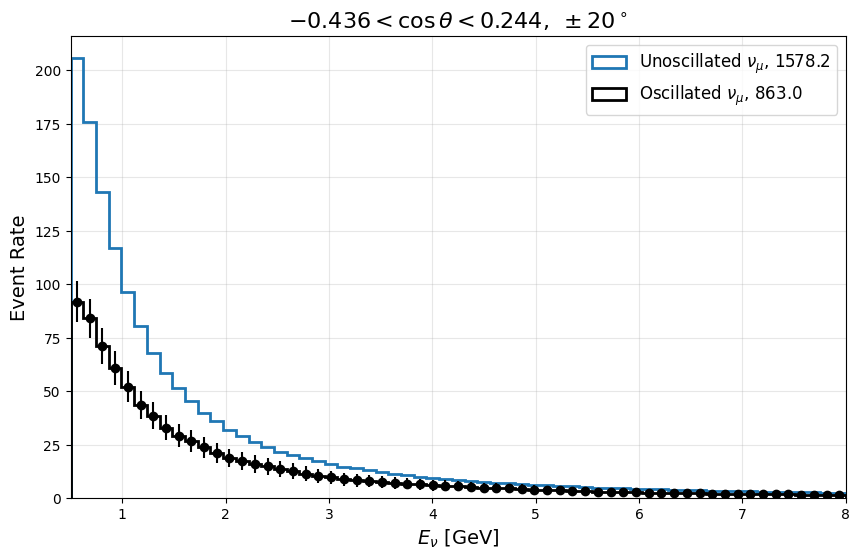

In [44]:
plot_ratio = False
delta_theta = 20
xsec = inter_xy(energy_bins_centers)
# 10^-38 cm^2 to m^2
conv = 1e-38 * 1e-4  # cm^2 to m^2
# number of argons for 20 kt FD
noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
scaled_xsec = conv*noar*xsec

# Integrate cos to get the total event rate
from scipy.integrate import simpson

def cos_lim(delta_theta):
    theta_0 = 95.85
    return (np.cos(np.radians(theta_0+delta_theta)), np.cos(np.radians(theta_0-delta_theta)))
cos_limit = cos_lim(delta_theta)
# Create integration grid for cos(theta)
cos_grid = np.linspace(cos_limit[0], cos_limit[1], 100)

# Calculate event rate for each energy bin
event_rate = np.zeros(len(energy_bins_centers))
event_rate_unosc = np.zeros(len(energy_bins_centers))

time_factor = 3 * 365.25 * 24 * 3600  # 3 years in seconds

# Energy bin width
energy_bin_width = energy_bins[1] - energy_bins[0]

for i, E in enumerate(energy_bins_centers):
    # Get flux, oscillation probability, and cross section for this energy
    flux_values = np.array([get_flux(cos, E)[0] for cos in cos_grid])
    osc_prob = np.array([osc_model(L_km=zenith_to_baseline(cos), E_GeV=E) for cos in cos_grid])
    
    # Integrand with oscillation: flux * p_mumu * xsec * 2pi (azimuthal integration) * time * dE
    integrand_osc = flux_values * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    # Integrand without oscillation: flux * xsec * 2pi * time * dE
    integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
    # Integrate over cos(theta)
    event_rate[i] = simpson(integrand_osc, cos_grid)
    event_rate_unosc[i] = simpson(integrand_unosc, cos_grid)

print(f"Energy bin width: {energy_bin_width:.3f} GeV")

# For histogram plotting
energy_bins_edges = energy_bins
# latex

plt.rcParams['text.usetex'] = False
plt.figure(figsize=(10, 6))
if plot_ratio is True:
    plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r'oscillated/unoscillated', linewidth=2)
    plt.ylabel(r"$P_{\mu\mu}^{\mathrm{eff}}$", fontsize=14)
else:
    plt.hist(energy_bins_centers, weights=event_rate_unosc, bins=energy_bins_edges, histtype="step", label=rf'Unoscillated $\nu_\mu$, ${np.sum(event_rate_unosc):.1f}$', linewidth=2)
    plt.hist(energy_bins_centers, weights=event_rate, bins=energy_bins_edges, histtype="step", label=rf'Oscillated $\nu_\mu$, ${np.sum(event_rate):.1f}$', linewidth=2, color = 'black')
    plt.errorbar(energy_bins_centers, event_rate, yerr=np.sqrt(event_rate), fmt='o', color='black')
    plt.ylabel("Event Rate", fontsize=14)

plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.title(rf"${cos_limit[0]:.3f} < \cos\theta < {cos_limit[1]:.3f},\; \pm {delta_theta}^\circ$", fontsize=16)
plt.grid(True, alpha=0.3)

plt.savefig(f"event_rate_with_atmos_+-{delta_theta}.pdf", dpi=300)
print(f"Total events (oscillated): {np.sum(event_rate):.2f}")
print(f"Total events (unoscillated): {np.sum(event_rate_unosc):.2f}")

Energy bin width: 0.123 GeV


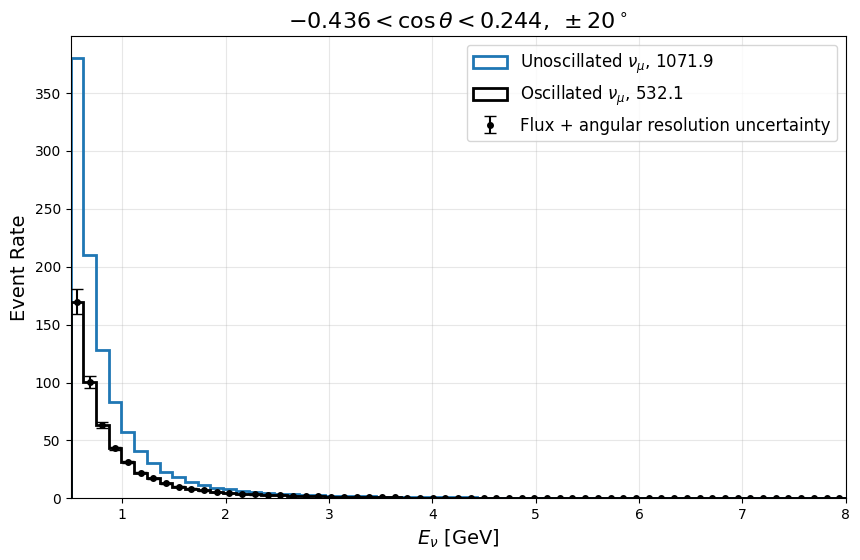

Total events (oscillated): 532.14
Total events (unoscillated): 1071.87
Total uncertainty: 21.88


In [35]:
plot_ratio = False
delta_theta = 20
xsec = inter_xy(energy_bins_centers)
# 10^-38 cm^2 to m^2
conv = 1e-38 * 1e-4  # cm^2 to m^2
# number of argons for 20 kt FD
noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
scaled_xsec = conv*noar*xsec

# Integrate cos to get the total event rate
from scipy.integrate import simpson

def cos_lim(delta_theta):
    theta_0 = 95.85 # zenith angle in degrees for the DUNE FD
    return (np.cos(np.radians(theta_0+delta_theta)), np.cos(np.radians(theta_0-delta_theta)))
cos_limit = cos_lim(delta_theta)
# Create integration grid for cos(theta)
cos_grid = np.linspace(cos_limit[0], cos_limit[1], 100)

# Calculate event rate for each energy bin
event_rate = np.zeros(len(energy_bins_centers))
event_rate_unosc = np.zeros(len(energy_bins_centers))
event_rate_uncertainty = np.zeros(len(energy_bins_centers))  # combined uncertainty

time_factor = 3 * 365.25 * 24 * 3600  # 3 years in seconds

# Energy bin width
energy_bin_width = energy_bins[1] - energy_bins[0]

for i, E in enumerate(energy_bins_centers):
    # Central flux, oscillation probability, and cross section for this energy
    flux_values = np.array([get_flux(cos, E)[0] for cos in cos_grid])
    flux_uncertainty = np.array([get_flux(cos, E, uncertainty=True)[0] for cos in cos_grid])
    
    osc_prob = np.array([osc_model(L_km=zenith_to_baseline(cos), E_GeV=E) for cos in cos_grid])
    
    # Angular resolution effect: baseline uncertainty from angular resolution
    ang_res_deg = angular_res[i]
    ang_res_rad = np.radians(ang_res_deg)
    
    # Compute oscillation probability uncertainty from angular resolution
    # Approximate: evaluate oscillation probability at perturbed baseline
    osc_prob_upper = np.zeros_like(cos_grid)
    osc_prob_lower = np.zeros_like(cos_grid)
    for j, cos in enumerate(cos_grid):
        baseline = zenith_to_baseline(cos)
        baseline_unc = 50 * ang_res_rad  # rough estimate: ~50 km per radian of uncertainty
        osc_prob_upper[j] = osc_model(L_km=baseline + baseline_unc, E_GeV=E)
        osc_prob_lower[j] = osc_model(L_km=baseline - baseline_unc, E_GeV=E)
    
    # Integrand with oscillation: flux * p_mumu * xsec * 2pi (azimuthal integration) * time * dE
    integrand_osc = flux_values * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    # Integrand without oscillation: flux * xsec * 2pi (azimuthal integration) * time * dE
    integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
    # Upper and lower with flux uncertainty
    integrand_osc_flux_upper = (flux_values + flux_uncertainty) * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    integrand_osc_flux_lower = (flux_values - flux_uncertainty) * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
    # Upper and lower with angular resolution uncertainty
    integrand_osc_ang_upper = flux_values * osc_prob_upper * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    integrand_osc_ang_lower = flux_values * osc_prob_lower * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
    
    # Integrate over cos(theta)
    event_rate[i] = simpson(integrand_osc, x=cos_grid)
    event_rate_unosc[i] = simpson(integrand_unosc, x=cos_grid)
    
    # Combine uncertainties: take maximum envelope
    rate_flux_upper = simpson(integrand_osc_flux_upper, x=cos_grid)
    rate_flux_lower = simpson(integrand_osc_flux_lower, x=cos_grid)
    rate_ang_upper = simpson(integrand_osc_ang_upper, x=cos_grid)
    rate_ang_lower = simpson(integrand_osc_ang_lower, x=cos_grid)
    
    # Combine by taking envelope (conservative)
    event_rate_uncertainty[i] = max(
        abs(rate_flux_upper - event_rate[i]),
        abs(event_rate[i] - rate_flux_lower),
        abs(rate_ang_upper - event_rate[i]),
        abs(event_rate[i] - rate_ang_lower)
    )

print(f"Energy bin width: {energy_bin_width:.3f} GeV")

# For histogram plotting
energy_bins_edges = energy_bins
plt.rcParams["text.usetex"] = False
plt.figure(figsize=(10, 6))

plt.hist(energy_bins_centers, weights=event_rate_unosc, bins=energy_bins_edges, histtype="step", 
         label=rf'Unoscillated $\nu_\mu$, ${np.sum(event_rate_unosc):.1f}$', linewidth=2)
plt.hist(energy_bins_centers, weights=event_rate, bins=energy_bins_edges, histtype="step", 
         label=rf'Oscillated $\nu_\mu$, ${np.sum(event_rate):.1f}$', linewidth=2, color='black')

# Combined error bars: flux + angular resolution uncertainties
plt.errorbar(energy_bins_centers, event_rate, yerr=event_rate_uncertainty, fmt='o', 
             color='black', markersize=4, capsize=4, label='Flux + angular resolution uncertainty')

plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel("Event Rate", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.title(rf"${cos_limit[0]:.3f} < \cos\theta < {cos_limit[1]:.3f},\; \pm {delta_theta}^\circ$", fontsize=16)
plt.grid(True, alpha=0.3)

plt.savefig(f"event_rate_with_uncertainties_+-{delta_theta}.pdf", dpi=300)
plt.show()

print(f"Total events (oscillated): {np.sum(event_rate):.2f}")
print(f"Total events (unoscillated): {np.sum(event_rate_unosc):.2f}")
print(f"Total uncertainty: {np.sum(event_rate_uncertainty):.2f}")

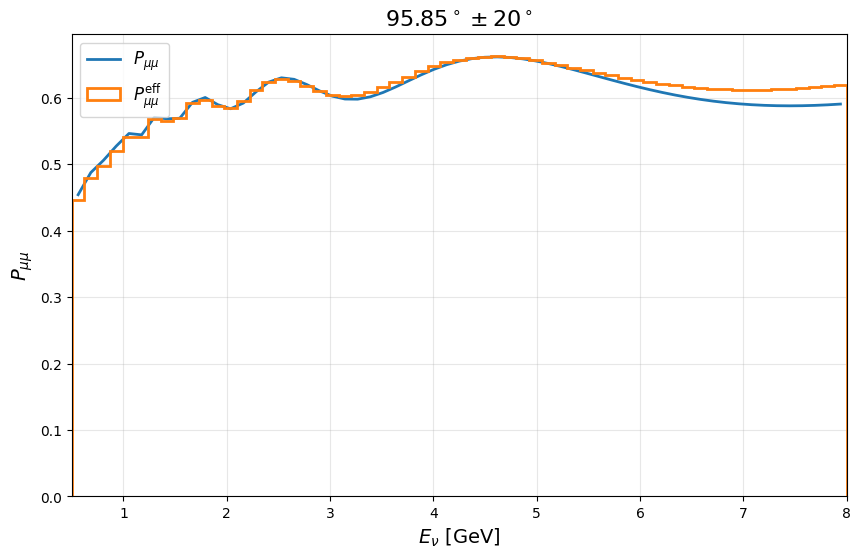

In [10]:
p_mm = np.zeros(len(energy_bins_centers))
for i in range(len(cos_grid)):
    p_mm += [osc_model(L_km=zenith_to_baseline(cos_grid[i]), E_GeV=E) for E in energy_bins_centers]
plt.figure(figsize=(10, 6))
plt.plot(energy_bins_centers, p_mm/100, label=r'$P_{\mu\mu}$', linewidth=2)
plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r"$P_{\mu\mu}^{\mathrm{eff}}$", linewidth=2)
plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(fr'$95.85^\circ \pm {delta_theta}^\circ$', fontsize=16)
plt.savefig(f"p_mumu_cos_{cos_limit[0]:.3f}_{cos_limit[1]:.3f}.pdf", dpi=300)

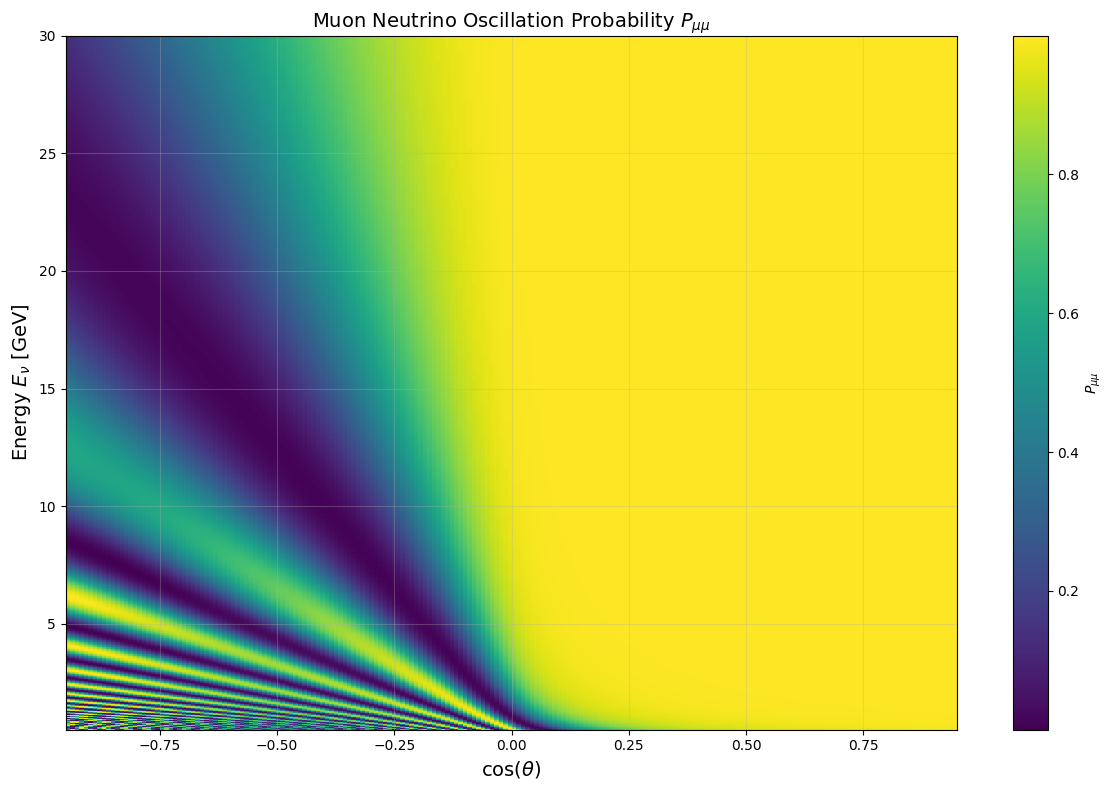

Probability range: 0.0000 to 1.0000


In [11]:

# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
# energies_for_heatmap = energy_bins_centers
energies_for_heatmap = np.linspace(0.5, 30, 1000)
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = osc_model(L_km=zenith_to_baseline(cos_z), E_GeV=E)

# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
#plt.yscale('log')
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu\mu}$', fontsize=14)

cbar = plt.colorbar(im, label=r'$P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_oscillogram.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


Difference between the two

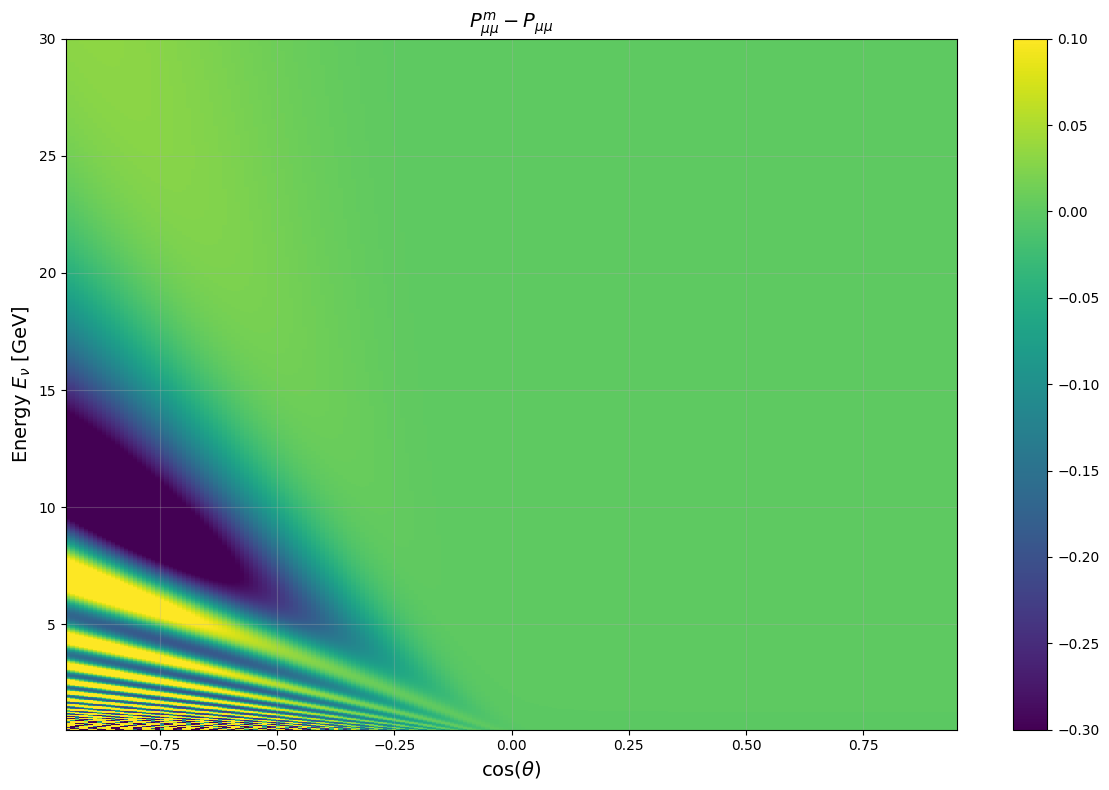

Probability range: -0.7320 to 0.8692


In [13]:

# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
# energies_for_heatmap = energy_bins_centers
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = osc_model(L_km=zenith_to_baseline(cos_z), E_GeV=E)-osc_model_vac(L_km=zenith_to_baseline(cos_z), E_GeV=E)
prob_min = prob_grid.min()
prob_max = prob_grid.max()
# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest', vmin = -0.3, vmax = 0.1)

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
#plt.yscale('log')
plt.title(r'$P_{\mu\mu}^m - P_{\mu\mu}$', fontsize=14)

cbar = plt.colorbar(im)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('p_mumu_oscillogram_diff.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


## energy dependent angular resolution

## flux uncertainty

## Sensitivity

In [ ]:
import tqdm as tqdm
Npoints = 100
s2theta = np.linspace(0.15, 0.85, Npoints)
dmSq = np.linspace(5e-4, 3e-3, Npoints)
parameter_grid = np.array(np.meshgrid(s2theta, dmSq)).T.reshape(-1, 2)
delta_theta = 20
cos_limit = cos_lim(delta_theta)
cos_grid = np.linspace(cos_limit[0], cos_limit[1], 100)

def p_mumu(cos_theta, energy, s2theta, dmSq):
    if cos_theta < 0:
        L = -2*r_e*cos_theta
    else:
        L = prop_length(cos_theta)
    return 1-4*s2theta*(1-s2theta)*np.sin(1.27*dmSq*L/energy)**2

def calculate_expected_events(s2thetaSq, dmSq):
    # allocate local arrays (avoid mutating globals)
    ev = np.zeros(len(energy_bins_centers))
    ev_un = np.zeros(len(energy_bins_centers))
    for i, E in enumerate(energy_bins_centers):
        flux_values = np.array([get_flux(cos, E)[0] for cos in cos_grid])
        osc_prob = np.array([p_mumu(cos, E, s2thetaSq, dmSq) for cos in cos_grid])
        integrand_osc = flux_values * osc_prob * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
        integrand_unosc = flux_values * scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width
        ev[i] = simpson(integrand_osc, cos_grid)
        ev_un[i] = simpson(integrand_unosc, cos_grid)
    return ev, ev_un


# def chi_squared(s2thetaSq, dmSq):
#     expected_events, bkg = calculate_expected_events(s2thetaSq, dmSq)
#     expected_events[expected_events == 0] = 1e-10
    
#     chi2 = np.sum((expected_events)**2 / bkg)
#     return chi2

# choose truth
s2_true = 0.55
dm_true = 2.44e-3

data, _ = calculate_expected_events(s2_true, dm_true)
data = data.copy()

def chi_squared(s2thetaSq, dmSq):
    pred, bkg = calculate_expected_events(s2thetaSq, dmSq)
    chi2 = np.sum((pred - data)**2 / data)
    #print(f"s2theta: {s2thetaSq:.3f}, dmSq: {dmSq:.3e}, chi2: {chi2:.2f}")
    return chi2


chi2_grid = np.zeros((Npoints, Npoints))
for i, s2 in enumerate(tqdm.tqdm(s2theta)):
    for j, dm in enumerate(dmSq):
        chi2_grid[i, j] = chi_squared(s2, dm)



 12%|█▏        | 12/100 [01:42<12:30,  8.53s/it]


KeyboardInterrupt: 

In [ ]:
nova_data = np.loadtxt('NOvA2024.dat', delimiter=',')

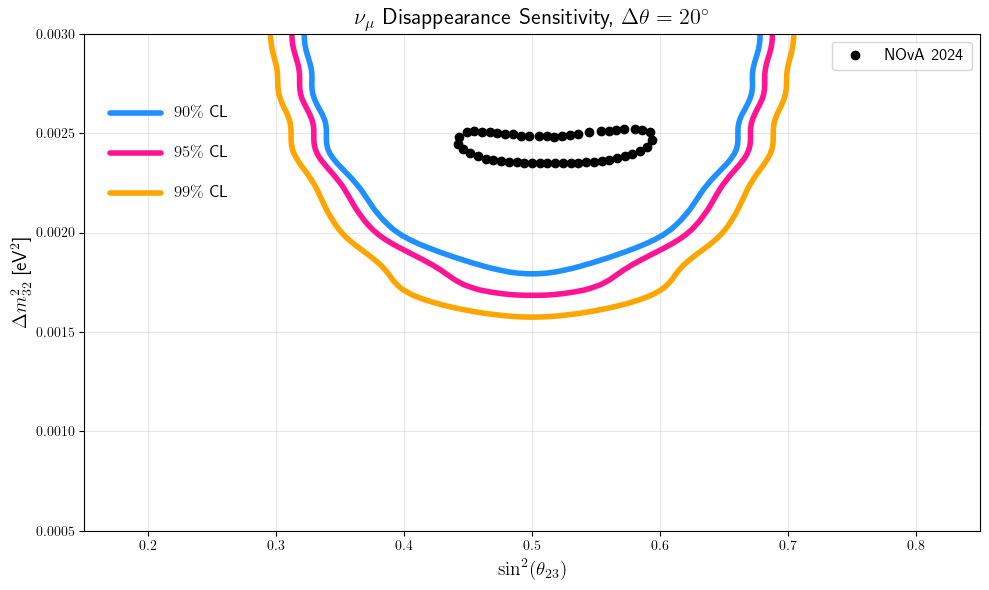

In [ ]:
# Plot chi-squared contours
# 90% CL for 2 parameters is 4.61, 95% CL is 5.99, 99% CL is 9.21
levels = [4.61, 5.99, 9.21] 
colors = ['dodgerblue', 'deeppink', 'orange']
plt.figure(figsize=(10, 6))
S2, DM = np.meshgrid(s2theta, dmSq)
CS = plt.contour(S2, DM, chi2_grid.T-np.min(chi2_grid), levels=levels, colors=colors, linewidths=4)
# plt.xlim(0.4, 0.6)
#plt.yscale('log')
#plt.ylim(2.35e-3, 2.6e-3)
#plt.ylim(5e-4, 1.5e-3)
plt.xlabel(r'$\sin^2(\theta_{23})$', fontsize=14)
plt.ylabel(r'$\Delta m^2_{32}$ [eV$^2$]', fontsize=14)

# Colored line swatches with black text labels
x0 = 0.17
x1 = 0.21
label_y = [2.6e-3, 2.4e-3, 2.2e-3]
labels = [r'$90\%$ CL', r'$95\%$ CL', r'$99\%$ CL']
for y, color, label in zip(label_y, colors, labels):
    plt.plot([x0, x1], [y, y], color=color, linewidth=4, solid_capstyle='round')
    plt.text(x1 + 0.01, y, label, fontsize=12, va='center', color='black')

# Add NOvA contour
nova_s2 = nova_data[:, 0]
nova_dm = nova_data[:, 1]/1e3
plt.plot(nova_s2, nova_dm, 'o', color='black', label='NOvA 2024')
plt.legend(fontsize=12)
plt.title(rf'$\nu_\mu$ Disappearance Sensitivity, $\Delta \theta = {delta_theta}^\circ$', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'chi_squared_contours_delta_theta_{delta_theta}.pdf', dpi=300)
plt.show()


## Matter effect spectrum

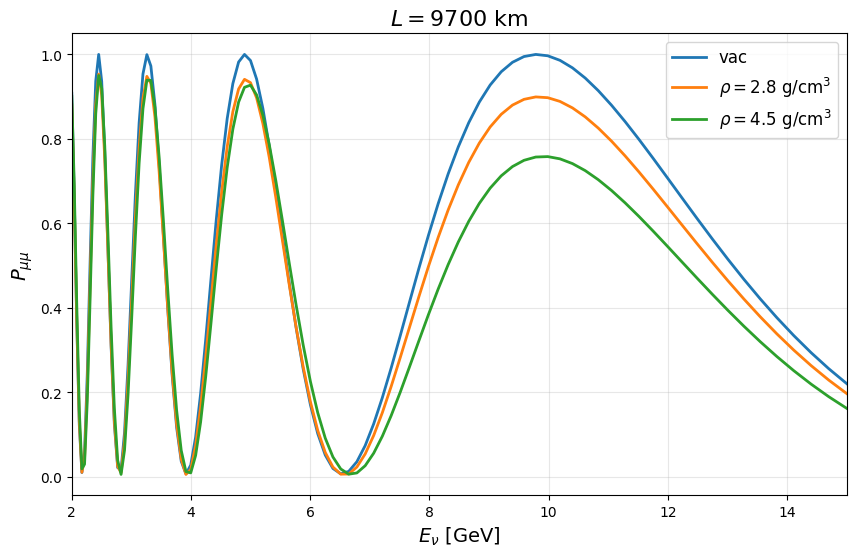

In [ ]:
rho_list = [2.8, 4.5]  # g/cm^3
energy_list = np.geomspace(2, 15, 100)
p_mumu_list = np.array([p_mumu_vac(x = 9700, E=i, baseline_type='km') for i in energy_list])

plt.figure(figsize=(10, 6))
plt.plot(energy_list, p_mumu_list, label=r'vac', linewidth=2)
for rho in rho_list:
    p_mumu_matter_list = np.array([p_mumu_matter(x = 9700, E=i, Ye = 0.5, rho = rho, baseline_type='km') for i in energy_list])
    plt.plot(energy_list, p_mumu_matter_list, label=r'$\rho = %.1f$ g/cm$^3$' % rho, linewidth=2)
plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(2, 15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(rf'$L = 9700$ km', fontsize=16)
plt.savefig(f"p_mumu_matter_9700km.pdf", dpi=300)

## Same baseline and energy, but different matter density

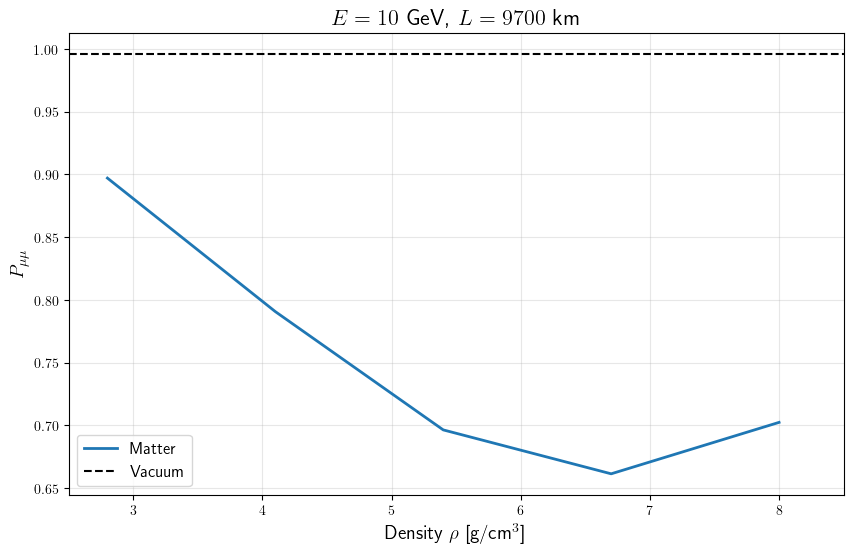

In [ ]:
rho_list = np.linspace(2.8, 8, 5)  # g/cm^3
energy = 10
baseline = 9700
p_mumu_vacuum = p_mumu_vac(x = baseline, E=energy, baseline_type='km')
p_mumu_matter_list = np.array([p_mumu_matter(energy, x = baseline, Ye = 0.5, rho = rho, baseline_type='km') for rho in rho_list])
plt.figure(figsize=(10, 6))
plt.plot(rho_list, p_mumu_matter_list, label=r'Matter', linewidth=2)
plt.axhline(p_mumu_vacuum, color='black', linestyle='--', label='Vacuum')
plt.xlabel(r"Density $\rho$ [g/cm$^3$]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(2.5, 8.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(rf'$E = {energy}$ GeV, $L = {baseline}$ km', fontsize=16)
plt.savefig(f"p_mumu_matter_vs_density.pdf", dpi=300)

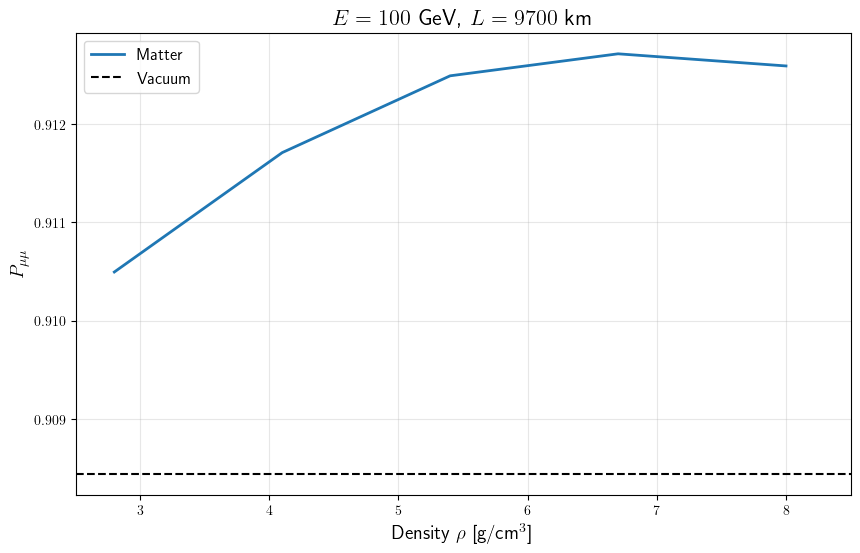

In [ ]:
rho_list = np.linspace(2.8, 8, 5)  # g/cm^3
energy = 100
baseline = 9700
p_mumu_vacuum = p_mumu_vac(x = baseline, E=energy, baseline_type='km')
p_mumu_matter_list = np.array([p_mumu_matter(energy, x = baseline, Ye = 0.5, rho = rho, baseline_type='km') for rho in rho_list])
plt.figure(figsize=(10, 6))
plt.plot(rho_list, p_mumu_matter_list, label=r'Matter', linewidth=2)
plt.axhline(p_mumu_vacuum, color='black', linestyle='--', label='Vacuum')
plt.xlabel(r"Density $\rho$ [g/cm$^3$]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(2.5, 8.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(rf'$E = {energy}$ GeV, $L = {baseline}$ km', fontsize=16)
plt.savefig(f"p_mumu_matter_vs_density.pdf", dpi=300)

In [ ]:
p_mumu_matter(1300,2.5, Ye = 0.5, rho =2.8, baseline_type='km')

np.float64(0.01363702065668598)